In [ ]:
%reload_ext autoreload
%autoreload 2

import os
from tqdm import tqdm
import gc

import numpy as np
import pickle
import jax
from jax import jit, vmap
import jax.numpy as jnp

from fpp.utils.cart import to_cart
from fpp.models.np_model import NPModel

%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
mpl.rc_file('matplotlibrc')

/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


In [ ]:
npmodel = NPModel()

samples = pickle.load(open('../outputs/production/fits/fermi/hmc.p', 'rb'))
samples.keys()

dict_keys(['Alm_0', 'Alm_1', 'Alm_2', 'Alm_3', 'Alm_4', 'C', 'S_bub', 'S_gce', 'S_ics', 'S_iso', 'S_pib', 'S_psc', 'Sps_dsk', 'Sps_gce', 'f_bulge_poiss', 'f_bulge_ps', 'gamma_poiss', 'gamma_ps', 'lambdas_dsk', 'lambdas_gce', 'n1_dsk', 'n1_gce', 'n2_dsk', 'n2_gce', 'n3_dsk', 'n3_gce', 'sb1_dsk', 'sb1_gce', 'theta_bulge_poiss', 'theta_bulge_ps', 'theta_ics', 'theta_pib', 'zs'])

In [9]:
def get_mask(extent=10, pixelsize=0.1, mask_b=2): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    mask_plane_cart = np.zeros((npixels, npixels), dtype=np.int32)
    i_mask_b_fm = int((extent - mask_b) / pixelsize)
    i_mask_b_to = int((extent + mask_b) / pixelsize)
    mask_plane_cart[i_mask_b_fm:i_mask_b_to] = 1
    return np.array(mask_plane_cart, dtype=bool)

mask = get_mask()

def get_t_med_var(ts, extent=10, pixelsize=0.1): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    t_med = jnp.median(ts, axis=0)
    t_var = jnp.quantile(ts, 0.84, axis=0) - jnp.quantile(ts, 0.16, axis=0)
    t_med_cart = to_cart(np.array(t_med), n_pixels=npixels, pixelsize=pixelsize)
    t_var_cart = to_cart(np.array(t_var), n_pixels=npixels, pixelsize=pixelsize)
    
    return t_med_cart, t_var_cart

def get_cart_from_hp(m, extent=10, pixelsize=0.1): # all in [deg]
    
    npixels = int(2 * extent / pixelsize)
    return to_cart(np.array(m), n_pixels=npixels, pixelsize=pixelsize)

## Load bulge templates (seperately)

In [5]:
from fpp.models.bulge_models import BulgeTemplates
from fpp.models.templates import NFWTemplate, LorimerDiskTemplate

In [6]:
nside = 128
bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']
bulge_templates = np.array([
    BulgeTemplates(template_name=n, nside_out=nside)()
    for n in bulge_names
])
nfw_template = NFWTemplate(nside=nside)
disk_template = LorimerDiskTemplate(nside=nside)

## Visualize bulges

In [7]:
extent = 10 # [deg]
pixelsize = 0.1
npixels = int(2 * extent / pixelsize)
mask_b = 2 # [deg]

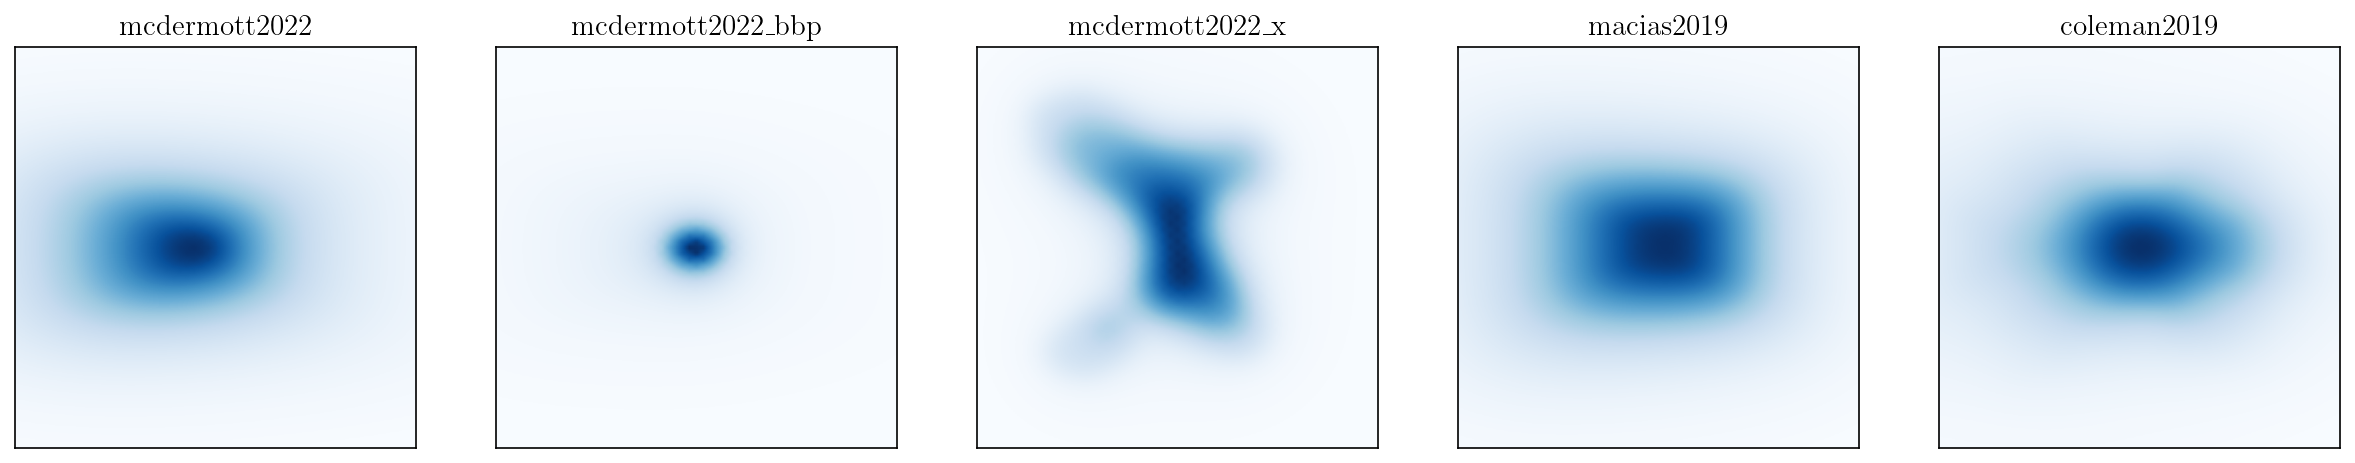

In [9]:
bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']

fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    axs[i].imshow(
        to_cart(np.array(npmodel.blg_s[i]), n_pixels=npixels, pixelsize=pixelsize),
        cmap='Blues'
    )
    axs[i].set(title=bulge_names[i], xticks=[], yticks=[])

## Get templates median & variation

In [5]:
t_dict = {}

In [ ]:
name = 'dsk'
n_plot = 1000

def get_dsk_templates(S, zs, C):
    return S * npmodel.dsk_temp_gen.get_template(zs=zs, C=C)

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_dsk_templates(samples['Sps_dsk'][i], samples['zs'][i], samples['C'][i]))
ts = np.array(ts)
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

100%|██████████| 1000/1000 [01:18<00:00, 12.81it/s]


In [19]:
name = 'gce_ps'
n_plot = 1000

def get_nfw_templates(S, gamma):
    return S * npmodel.nfw_temp_gen.get_NFW2_template(gamma=gamma)
def get_blg_templates(S, theta):
    return S * jnp.dot(theta, npmodel.blg_s)
def get_gce_templates(S_gce, f_bulge, gamma, theta):
    return get_nfw_templates(S_gce*(1-f_bulge), gamma) + get_blg_templates(S_gce*f_bulge, theta)

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_gce_templates(
        samples['Sps_gce'][i],
        samples['f_bulge_ps'][i],
        samples['gamma_ps'][i],
        samples['theta_bulge_ps'][i]
    ))
ts = np.array(ts)

t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

100%|██████████| 1000/1000 [00:34<00:00, 28.83it/s]


253

In [22]:
name = 'gce_poiss'
n_plot = 1000

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_gce_templates(
        samples['S_gce'][i],
        samples['f_bulge_poiss'][i],
        samples['gamma_poiss'][i],
        samples['theta_bulge_poiss'][i]
    ))
ts = np.array(ts)

t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

100%|██████████| 1000/1000 [00:39<00:00, 25.30it/s]


0

In [26]:
name = 'blg_ps'
n_plot = 1000

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_blg_templates(
        samples['Sps_gce'][i] * samples['f_bulge_ps'][i],
        samples['theta_bulge_ps'][i]
    ))
ts = np.array(ts)
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [00:01<00:00, 632.28it/s]


1106

In [27]:
name = 'blg_poiss'
n_plot = 1000

ts = []
for i in tqdm(range(n_plot)):
    ts.append(get_blg_templates(
        samples['S_gce'][i] * samples['f_bulge_poiss'][i],
        samples['theta_bulge_poiss'][i]
    ))
ts = np.array(ts)
t_dict[name+'_med'], t_dict[name+'_var'] = get_t_med_var(ts)

del ts
gc.collect()

100%|██████████| 1000/1000 [00:01<00:00, 631.69it/s]


0

In [37]:
print(t_dict.keys())
pickle.dump(t_dict, open('../outputs/production/gce_shape_data.p', 'wb'))

dict_keys(['dsk_med', 'dsk_var', 'gce_ps_med', 'gce_ps_var', 'gce_poiss_med', 'gce_poiss_var', 'blg_ps_med', 'blg_ps_var', 'blg_poiss_med', 'blg_poiss_var', 'gamma_ps_best_fit', 'gamma_poiss_best_fit'])


# gamma best fits

In [29]:
from scipy.optimize import curve_fit

def gaussian(x, amp, mu, sigma):
    return amp * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

def find_peak_value(data, n_bins=50, plot=False):

    counts, bin_edges = np.histogram(data, bins=n_bins)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    i_max = np.argmax(counts)
    p0 = [counts[i_max], bin_centers[i_max], np.std(data)]

    popt, pcov = curve_fit(gaussian, bin_centers, counts, p0=p0)
    amp_fit, mu_fit, sigma_fit = popt

    if plot:
        x_fine = np.linspace(bin_edges[0], bin_edges[-1], 300)
        y_fine = gaussian(x_fine, *popt)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.hist(data, bins=n_bins, alpha=0.6, color="steelblue", edgecolor="white", label="Data")
        ax.plot(x_fine, y_fine, "r-", lw=2, label=f"Gaussian fit\n$\\mu={mu_fit:.3f}$, $\\sigma={abs(sigma_fit):.3f}$")
        ax.axvline(mu_fit, color="r", ls="--", lw=1, alpha=0.7, label=f"Peak at {mu_fit:.3f}")
        ax.set_xlabel("Value")
        ax.set_ylabel("Counts")
        ax.legend()
        ax.set_title("Gaussian Fit to Histogram")
        plt.tight_layout()
        plt.show()

    return mu_fit

In [33]:
t_dict['gamma_ps_best_fit'] = find_peak_value(samples['gamma_ps'])
t_dict['gamma_poiss_best_fit'] = find_peak_value(samples['gamma_poiss'])

# plot

In [4]:
bulge_names = ['mcdermott2022', 'mcdermott2022_bbp', 'mcdermott2022_x', 'macias2019', 'coleman2019']

options = {
    'dsk'       : dict(plot_bulge=None, plot_nfw=False, n_level=10, title='Disk Point Source'),
    'gce_ps'    : dict(plot_bulge='blg_ps_med', plot_nfw=True, n_level=7, title='GCE Point Source'),
    'gce_poiss' : dict(plot_bulge='blg_poiss_med', plot_nfw=True, n_level=7, title='GCE Diffuse'),
}

In [ ]:
t_dict = pickle.load(open('../outputs/production/gce_shape_data.p', 'rb'))

/tmp/ipykernel_3936306/3832303963.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  main_cmap = mpl.cm.get_cmap('Blues')


/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/IPython/core/events.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  func(*args, **kwargs)
/n/home07/yitians/.conda/envs/torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:152: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


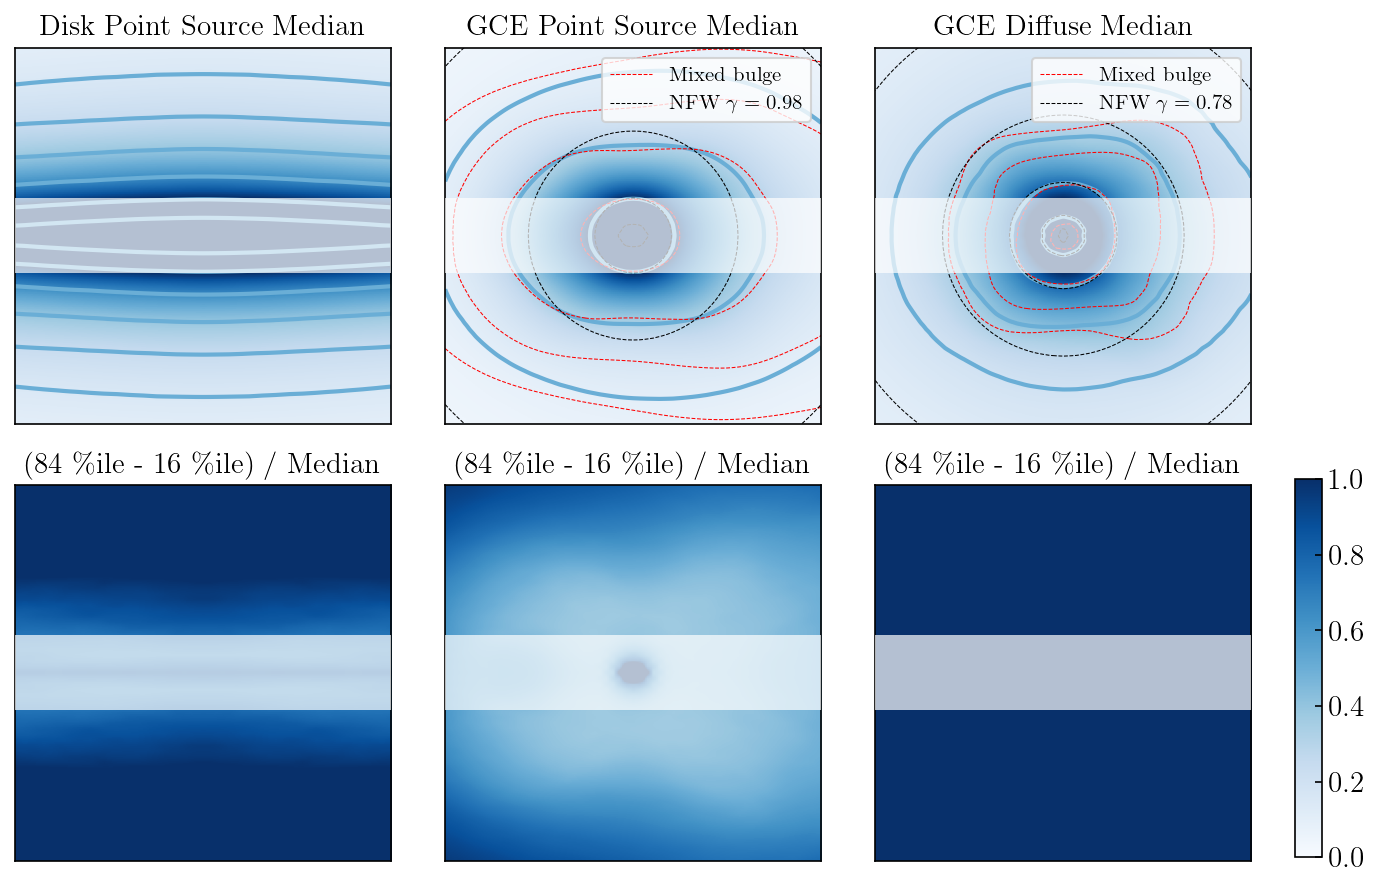

In [12]:
n_plot = len(options.items())
extent = 10
mask_b = 2
plot_extent = (-extent, extent, extent, -extent)

main_cmap = mpl.cm.get_cmap('Blues')

fig, axs = plt.subplots(2, n_plot, figsize=(3*n_plot, 6), tight_layout=True)

for i, (name, option) in enumerate(options.items()):

    t_med = np.array(t_dict[name+'_med'])
    t_var = np.array(t_dict[name+'_var'])
    
    vmax_masked = np.max(t_med[~mask])
    vmax = np.max(t_med)
    if name == 'dsk':
        levels = np.geomspace(0.1, vmax, option['n_level'])
    else:
        levels = np.geomspace(0.7, vmax, 5)
    
    axs[0,i].imshow(np.flip(t_med), vmax=vmax_masked, vmin=0, cmap=main_cmap, extent=plot_extent)
    cs = axs[0,i].contour(np.flip(t_med), colors=mpl.colors.to_hex(main_cmap(0.5), keep_alpha=True),
                          levels=levels, extent=plot_extent, linewidths=2)
    
    have_legend = False
    if option['plot_bulge'] is not None:
        have_legend = True
        plot_one_bulge = False
        if plot_one_bulge:
            i_blg = bulge_names.index(option['plot_bulge'])
            t_blg = get_cart_from_hp(npmodel.bulge_templates[i_blg]) # plot one bulge
        else:
            t_blg = t_dict[option['plot_bulge']] # plot average bulge 
        vmax_masked_blg = np.max(t_blg[~mask])
        t_blg *= vmax_masked / vmax_masked_blg
        vmax_blg = np.max(t_blg)
        cs1 = axs[0,i].contour(np.flip(t_blg), colors='red', levels=levels,
                         linestyles='--', extent=plot_extent, linewidths=0.5)
        h1, _ = cs1.legend_elements()
        
    if option['plot_nfw']:
        have_legend = True
        if 'ps' in name:
            # gamma_best_fit = t_dict['gamma_ps_best_fit']
            gamma_best_fit = np.median(samples['gamma_ps'])
        else:
            # gamma_best_fit = t_dict['gamma_poiss_best_fit']
            gamma_best_fit = np.median(samples['gamma_poiss'])
        t_nfw = get_cart_from_hp(npmodel.nfw_temp_gen.get_NFW2_template(gamma=gamma_best_fit))
        vmax_masked_nfw = np.max(t_nfw[~mask])
        t_nfw *= vmax_masked / vmax_masked_nfw
        vmax_nfw = np.max(t_nfw)
        cs2 = axs[0,i].contour(np.flip(t_nfw), colors='k', levels=levels,
                         linestyles='--', extent=plot_extent, linewidths=0.5)
        h2, _ = cs2.legend_elements()
        
    if have_legend:
        axs[0,i].legend([h1[0], h2[0]], ['Mixed bulge', f'NFW $\gamma={gamma_best_fit:.2f}$'], fontsize=10)
    
    axs[0,i].fill_between([-extent, extent], [-mask_b, -mask_b], [+mask_b, +mask_b], color='white', alpha=0.7, ec='none', zorder=10)
    axs[1,i].fill_between([-extent, extent], [-mask_b, -mask_b], [+mask_b, +mask_b], color='white', alpha=0.7, ec='none', zorder=10)
    
    im = axs[1,i].imshow(np.flip(t_var)/np.flip(t_med), vmax=1, vmin=0, cmap=main_cmap, extent=plot_extent)
    axs[0,i].set(xticks=[], yticks=[], title=option['title']+' Median')
    axs[1,i].set(xticks=[], yticks=[], title='(84 \%ile - 16 \%ile) / Median')
    
cax = fig.add_axes([0.99, 0.034, 0.02, 0.42])
fig.colorbar(axs[1, 2].images[0], cax=cax, aspect=40)
# plt.savefig('templates.pdf')